# MLP (Adam Optimizer)

## Import Library

In [31]:
# 1. IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from statsmodels.graphics.tsaplots import plot_acf
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore")

## Konfigurasi parameter
Mengatur seed untuk reproducibility dan mendefinisikan parameter utama untuk model dan proses training.

In [23]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Parameter utama
FILE_PATH = "bbri_2025.xlsx"
SHEET_NAME = 'Sheet1'
TARGET_COLUMN = 'Close'
MAX_LOOK_BACK = 5  # Maksimum look_back untuk tuning
EPOCHS = 100
BATCH_SIZE = 32
TUNER_MAX_TRIALS = 15
TUNER_EPOCHS = 100
TEST_DAYS = 7  # Jumlah hari untuk data test

In [25]:
def create_dataset_mlp(dataset, look_back=1):
    """
    Mengubah array nilai menjadi format dataset untuk MLP.
    Contoh:
    dataset = [1, 2, 3, 4, 5]
    look_back = 2
    Maka hasilnya:
    dataX = [[1, 2], [2, 3], [3, 4]]
    dataY = [3, 4, 5]
    """
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        # Ambil sequence [i] s/d [i+look_back] sebagai fitur
        a = dataset[i:(i + look_back), 0]
        dataX.append(a)
        # Ambil data [i + look_back] sebagai target
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

## Persiapan data

In [26]:
from IPython.display import display, HTML

print(f"Memuat data dari {FILE_PATH} (Fitur: {TARGET_COLUMN})...")
df = pd.read_excel(
    FILE_PATH,
    sheet_name=SHEET_NAME,
    usecols=['Date', TARGET_COLUMN],
    parse_dates=['Date'],
    index_col='Date',
    engine='openpyxl'
)
df = df.dropna()

print("\nPreview Data:")
display(df.head())

dataset_values = df[TARGET_COLUMN].values.reshape(-1, 1).astype('float32')

Memuat data dari bbri_2025.xlsx (Fitur: Close)...

Preview Data:


,Close
Date,
2025-01-02,4210
2025-01-03,4150
2025-01-06,4100
2025-01-07,4030
2025-01-08,4080


<Figure size 1000x600 with 0 Axes>

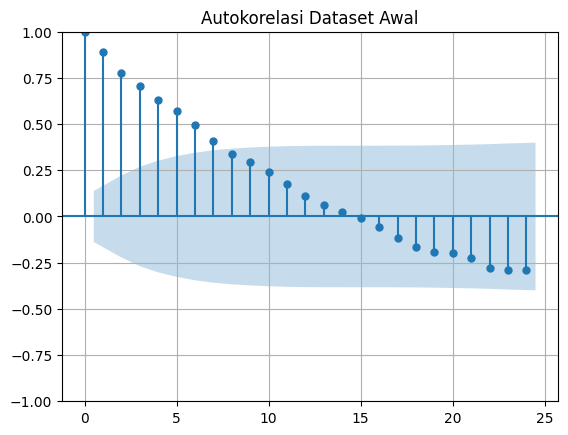

In [27]:
plt.figure(figsize=(10,6))
plot_acf(dataset_values, alpha=0.05)
plt.title('Autokorelasi Dataset Awal')
plt.grid(True)
plt.show()

### Preprocessing 
Split dataset menjadi train dan test, lakukan normalisasi, dan transformasi ke format supervised learning.

In [28]:
# Split dataset sebelum scaling
train_size = len(dataset_values) - TEST_DAYS
train_values = dataset_values[:train_size]
test_values  = dataset_values[train_size:]

print(f"\nJumlah data training: {len(train_values)}")
print(f"Jumlah data testing: {len(test_values)} (7 hari)")

# Fit scaler hanya pada data training
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_values)
scaled_train = scaler.transform(train_values)
scaled_test  = scaler.transform(test_values)

# Buat dataset MLP dengan look_back maksimum
X_train, y_train = create_dataset_mlp(scaled_train, MAX_LOOK_BACK)
X_test, y_test   = create_dataset_mlp(scaled_test, MAX_LOOK_BACK)
print(f"Shape X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape X_test: {X_test.shape}, y_test: {y_test.shape}")


Jumlah data training: 194
Jumlah data testing: 7 (7 hari)
Shape X_train: (189, 5), y_train: (189,)
Shape X_test: (2, 5), y_test: (2,)


## Pemodelan

### Definisi Arsitektur Model

In [29]:
def build_model(hp):
    model = Sequential()
    hp_units = hp.Int('units_layer1', min_value=32, max_value=256, step=32)
    hp_layers = hp.Int('num_layers', min_value=1, max_value=3)
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    hp_look_back = hp.Int('look_back', min_value=1, max_value=5)
    
    # Layer untuk memilih kolom sesuai look_back
    # Mengambil hp_look_back kolom terakhir dari input
    model.add(Lambda(lambda x: x[:, -hp_look_back:], input_shape=(MAX_LOOK_BACK,)))
    
    model.add(Dense(hp_units, activation='relu'))
    for i in range(hp_layers - 1):
        hp_units_hidden = hp.Int(f'units_layer_{i+2}', min_value=32, max_value=128, step=32)
        model.add(Dense(hp_units_hidden, activation='relu'))
    model.add(Dense(1))
    model.compile(
        optimizer=Adam(learning_rate=hp_lr),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

### Hyperparameter tunning
Pencarian hyperparameter terbaik menggunakan Keras Tuner dengan metode Random Search.

In [32]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=TUNER_MAX_TRIALS,
    executions_per_trial=1,
    directory='tuning_results_mlp_uni',
    project_name='bbri_forecasting_mlp_uni'
)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\nMulai Hyperparameter Tuning (MLP Univariate dengan Look_Back Tuning)...")
tuner.search(
    X_train, y_train,
    epochs=TUNER_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1
)

best_hps = tuner.get_best_hyperparameters(1)[0]
print(f"\n--- HYPERPARAMETER TERBAIK ---")
print(f"Look Back      : {best_hps.get('look_back')}")
print(f"Learning Rate  : {best_hps.get('learning_rate')}")
print(f"Num Layers     : {best_hps.get('num_layers')}")
print(f"Units Layer 1  : {best_hps.get('units_layer1')}")
print("------------------------------------------")

Trial 15 Complete [00h 00m 06s]
val_loss: 0.01439131423830986

Best val_loss So Far: 0.004359448328614235
Total elapsed time: 00h 01m 57s

--- HYPERPARAMETER TERBAIK ---
Look Back      : 1
Learning Rate  : 0.01
Num Layers     : 2
Units Layer 1  : 160
------------------------------------------


### Training model final
Membangun dan melatih model dengan hyperparameter terbaik

In [33]:
print("\nMembangun model final dengan hyperparameter terbaik...")
model = build_model(best_hps)
model.summary()

early_stopping_final = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print(f"\nMulai training model FINAL (Epochs={EPOCHS}, Batch Size={BATCH_SIZE})...")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[early_stopping_final],
    shuffle=False,
    verbose=1
)
print("Training final selesai.")


Membangun model final dengan hyperparameter terbaik...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 160)            │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,689 (41.75 KB)

 Trainable params: 10,689 (41.75 KB)

 Non-trainable params: 0 (0.00 B)


Mulai training model FINAL (Epochs=100, Batch Size=32)...
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.1048 - mae: 0.2551 - val_loss: 0.0490 - val_mae: 0.2117
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0231 - mae: 0.1199 - val_loss: 0.0127 - val_mae: 0.0931
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0176 - mae: 0.1031 - val_loss: 0.0113 - val_mae: 0.0869
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0136 - mae: 0.0944 - val_loss: 0.0090 - val_mae: 0.0774
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0100 - mae: 0.0790 - val_loss: 0.0053 - val_mae: 0.0628
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0089 - mae: 0.0737 - val_loss: 0.0077 - val_mae: 0.0726
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0089 - mae: 0.0725 - val_loss: 0.0050 - val_mae: 0.0591
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0083 - mae: 0.0691 - val_loss: 0.0045 - val_mae: 0.0568
Epoch 9/100
5

### Visualisasi loss training

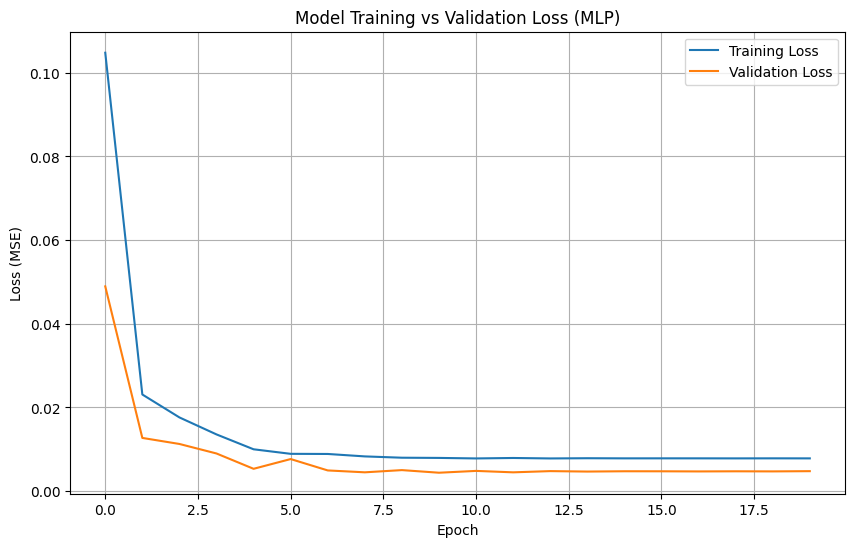

In [34]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training vs Validation Loss (MLP)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

## Evaluasi model

### Prediksi dan invers transform

In [35]:
# Prediksi
train_predict = model.predict(X_train)
test_predict  = model.predict(X_test)

# Kembalikan ke skala asli
train_predict_orig = scaler.inverse_transform(train_predict)
test_predict_orig  = scaler.inverse_transform(test_predict)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_orig  = scaler.inverse_transform(y_test.reshape(-1, 1))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


### Metrik evaluasi
Perhitungan RMSE, MAE, dan MAPE untuk mengukur akurasi model.

In [36]:
train_rmse = math.sqrt(mean_squared_error(y_train_orig, train_predict_orig))
test_rmse = math.sqrt(mean_squared_error(y_test_orig, test_predict_orig))
train_mae = mean_absolute_error(y_train_orig, train_predict_orig)
test_mae = mean_absolute_error(y_test_orig, test_predict_orig)

epsilon = 1e-10
train_mape = np.mean(np.abs((y_train_orig - train_predict_orig) / (y_train_orig + epsilon))) * 100
test_mape = np.mean(np.abs((y_test_orig - test_predict_orig) / (y_test_orig + epsilon))) * 100

print(f"\n--- HASIL EVALUASI ---")
print(f"Train RMSE : {train_rmse:.2f}")
print(f"Test  RMSE : {test_rmse:.2f}")
print(f"Train MAE  : {train_mae:.2f}")
print(f"Test  MAE  : {test_mae:.2f}")
print(f"Train MAPE : {train_mape:.2f}%")
print(f"Test  MAPE : {test_mape:.2f}%")


--- HASIL EVALUASI ---
Train RMSE : 93.18
Test  RMSE : 25.66
Train MAE  : 69.55
Test  MAE  : 19.67
Train MAPE : 1.79%
Test  MAPE : 0.49%


In [ ]:
### Visualisasi hasil prediksi

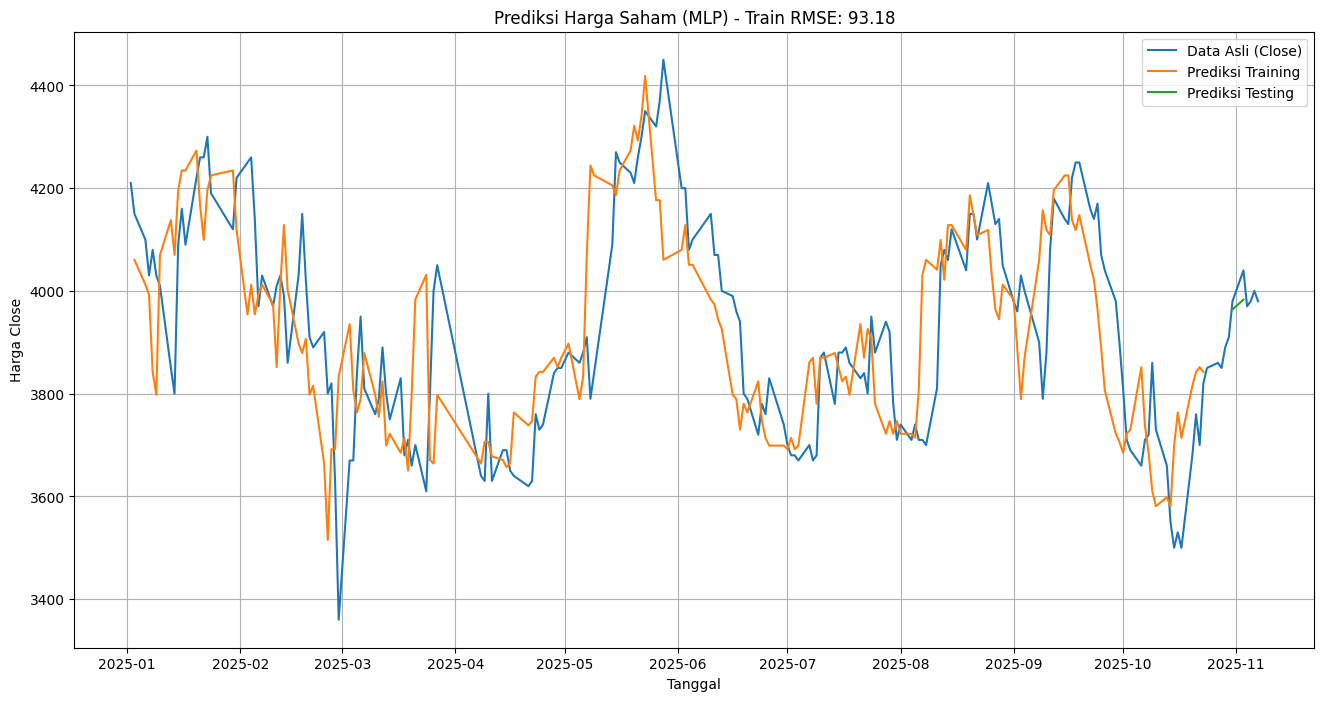

In [42]:
# Ambil look_back terbaik dari tuner
best_look_back = best_hps.get('look_back')

# Array kosong untuk plot dalam skala asli
full_true = dataset_values.copy()
train_plot = np.full_like(full_true, np.nan)
test_plot  = np.full_like(full_true, np.nan)

# Offset indexing training
# Training prediction dimulai setelah "best_look_back" data pertama
train_start = best_look_back
train_end   = train_start + len(train_predict_orig)

train_plot[train_start:train_end, 0] = train_predict_orig.flatten()

# Offset indexing testing
# Test dimulai dari posisi train_size (bagian akhir sebelum 7 hari)
test_start = len(dataset_values) - TEST_DAYS + best_look_back
test_end   = test_start + len(test_predict_orig)

test_plot[test_start:test_end, 0] = test_predict_orig.flatten()

# Plot
plt.figure(figsize=(16,8))
plt.plot(df.index, full_true, label='Data Asli (Close)')
plt.plot(df.index, train_plot, label='Prediksi Training')
plt.plot(df.index, test_plot, label='Prediksi Testing')
plt.title(f'Prediksi Harga Saham (MLP) - Train RMSE: {train_rmse:.2f}')
plt.xlabel('Tanggal')
plt.ylabel('Harga Close')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
### Autokorelasi residu

<Figure size 1000x600 with 0 Axes>

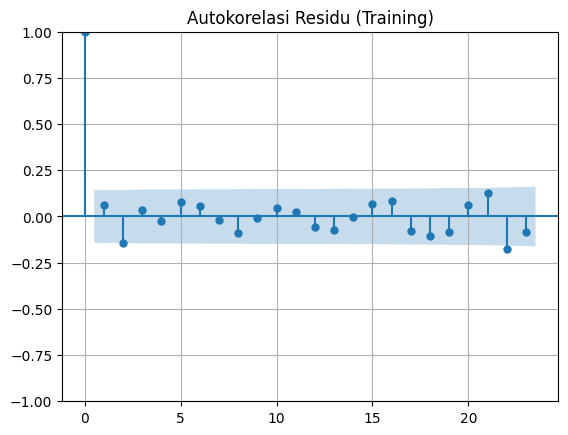

In [40]:
train_residuals = y_train_orig.flatten() - train_predict_orig.flatten()

plt.figure(figsize=(10,6))
plot_acf(train_residuals, alpha=0.05)
plt.title('Autokorelasi Residu (Training)')
plt.grid(True)
plt.show()

### Cek Autokorelasi dengan Ljung-box

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd

def diagnosis_ljungbox(residuals, title="Uji Ljung-Box"):
    """
    Melakukan Uji Ljung-Box untuk mendeteksi autokorelasi pada residu.
    H0: Data bersifat acak (White Noise) -> MODEL BAGUS
    H1: Data memiliki autokorelasi (Ada pola tertinggal) -> MODEL KURANG
    """
    print(f"--- {title} ---")
    
    # Kita cek hingga lag 10 (bisa disesuaikan)
    # return_df=True agar outputnya rapi dalam bentuk tabel
    lb_test = acorr_ljungbox(residuals, lags=[5, 10, 15, 20], return_df=True)
    
    print(lb_test)
    
    # Cek cepat untuk Lag 10
    p_val_10 = lb_test.loc[10, 'lb_pvalue']
    if p_val_10 > 0.05:
        print(f"\nKesimpulan (Lag 10): ✅ LULUS (p-value {p_val_10:.4f} > 0.05)")
        print("Residu bersifat acak (White Noise). Model berhasil menangkap pola.")
    else:
        print(f"\nKesimpulan (Lag 10): ❌ GAGAL (p-value {p_val_10:.4f} < 0.05)")
        print("Residu TIDAK acak. Masih ada pola yang tertinggal di error.")
    print("-" * 50 + "\n")

# --- JALANKAN FUNGSI ---
# Pastikan variabel train_residuals dan test_residuals sudah ada dari cell sebelumnya
diagnosis_ljungbox(train_residuals, "Diagnostik Residu Training")

--- Diagnostik Residu Training ---
      lb_stat  lb_pvalue
5    6.233384   0.284168
10   8.809366   0.550286
15  11.587594   0.709938
20  18.956853   0.524632

Kesimpulan (Lag 10): ✅ LULUS (p-value 0.5503 > 0.05)
Residu bersifat acak (White Noise). Model berhasil menangkap pola.
--------------------------------------------------

--- Diagnostik Residu Testing ---
    lb_stat  lb_pvalue
5       inf        0.0
10      inf        0.0
15      inf        0.0
20      inf        0.0

Kesimpulan (Lag 10): ❌ GAGAL (p-value 0.0000 < 0.05)
Residu TIDAK acak. Masih ada pola yang tertinggal di error.
--------------------------------------------------



# MLP (SDG Optimizer)